# 2.2 DustPy Basics

[DustPy](https://stammler.github.io/dustpy/) is derived from Simframe.  
After working on the Simframe notebook you should find many similarities.

## The simulation frame

The DustPy package contains the `Simulation` class which is a Simframe simulation frame pre-filled with fields used by DustPy.

In [1]:
from dustpy import Simulation

In [2]:
sim = Simulation()

In [3]:
sim

DustPy
------
    dust         : Group (Dust quantities)
    gas          : Group (Gas quantities)
    grid         : Group (Grid quantities)
    star         : Group (Stellar quantities)
  -----
    t            : NoneType
  -----
    Integrator   : not specified
    Writer       : not specified

At this point the Frame is empty and all field are initialized with `None`:

In [4]:
sim.gas.Sigma is None

True

## Initializing

At this point we can set some nasic initial conditions in a dedicated group within the Simulation frame.  
For a detailed description of these values please consult the [documentation](https://stammler.github.io/dustpy/2_simple_customization.html).

In [5]:
sim.ini

namespace(dust=namespace(aIniMax=0.0001,
                         allowDriftingParticles=False,
                         erosionMassRatio=10.0,
                         d2gRatio=0.01,
                         distExp=-3.5,
                         excavatedMass=1.0,
                         fragmentDistribution=-1.8333333333333333,
                         rhoMonomer=1.67,
                         vFrag=100.0),
          gas=namespace(alpha=0.001,
                        Mdisk=9.942049353490256e+31,
                        mu=3.847030424486999e-24,
                        SigmaExp=-1.0,
                        SigmaRc=897587224200000.0),
          grid=namespace(Nmbpd=7,
                         mmin=1e-12,
                         mmax=100000.0,
                         Nr=100,
                         rmin=14959787070000.0,
                         rmax=1.495978707e+16),
          star=namespace(M=1.988409870698051e+33, R=139140000000.0, T=5772.0))

When initializing the simulation frame, DustPy will fill all fields with default values. The units are cgs units.

In [6]:
sim.initialize()

In [7]:
sim.gas

Group (Gas quantities)
----------------------
    boundary     : Group (Boundary conditions)
    S            : Group (Source terms)
    torque       : Group (Torque parameters)
    v            : Group (Velocities)
  -----
    alpha        : Field (Turbulent alpha parameter)
    cs           : Field (Isothermal sound speed [cm/s])
    eta          : Field (Pressure gradient parameter)
    Fi           : Field (Gas flux interfaces [g/cm/s])
    Hp           : Field (Pressure scale height [cm])
    mfp          : Field (Midplane mean free path [cm])
    mu           : Field (Mean molecular weight [g])
    n            : Field (Miplane number density [1/cm³])
    nu           : Field (Kinematic viscosity [cm²/s])
    P            : Field (Midplane pressure [g/cm/s²])
    rho          : Field (Miplane mass density [g/cm³])
    Sigma        : Field (Surface density [g/cm²])
    SigmaFloor   : Field (Floor value of surface density [g/cm²])
    T            : Field (Temperature [K])
  -----

In [8]:
sim.gas.Sigma

[1.11815368e+003 1.04232155e+003 9.71465059e+002 9.05339692e+002
 8.43629793e+002 7.86040780e+002 7.32297742e+002 6.82144128e+002
 6.35340519e+002 5.91663488e+002 5.50904531e+002 5.12869076e+002
 4.77375546e+002 4.44254502e+002 4.13347826e+002 3.84507969e+002
 3.57597248e+002 3.32487186e+002 3.09057900e+002 2.87197527e+002
 2.66801690e+002 2.47773001e+002 2.30020595e+002 2.13459693e+002
 1.98011200e+002 1.83601326e+002 1.70161231e+002 1.57626698e+002
 1.45937826e+002 1.35038739e+002 1.24877321e+002 1.15404966e+002
 1.06576343e+002 9.83491798e+001 9.06840556e+001 8.35442144e+001
 7.68953850e+001 7.07056150e+001 6.49451154e+001 5.95861146e+001
 5.46027226e+001 4.99708026e+001 4.56678518e+001 4.16728886e+001
 3.79663471e+001 3.45299782e+001 3.13467557e+001 2.84007884e+001
 2.56772375e+001 2.31622377e+001 2.08428234e+001 1.87068586e+001
 1.67429708e+001 1.49404882e+001 1.32893806e+001 1.17802035e+001
 1.04040457e+001 9.15247991e+000 8.01751688e+000 6.99156307e+000
 6.06738170e+000 5.238057

The full tree structure can be displayed as well.

In [9]:
sim.toc

DustPy
    - dust: Group (Dust quantities)
        - a: Field (Particle size [cm])
        - backreaction: Group (Backreaction coefficients)
            - A: Field (Pull factor)
            - B: Field (Push factor)
        - boundary: Group (Boundary conditions)
            - inner: Constant gradient
            - outer: Value
        - coagulation: Group (Coagulation quantities)
            - A: Field (Fragment normalization factors), constant
            - eps: Field (Remnant mass distribution), constant
            - lf_ind: Field (Index of largest fragment), constant
            - phi: Field (Fragment distribution), constant
            - rm_ind: Field (Smaller index of remnant), constant
            - stick: Field (Sticking matrix), constant
            - stick_ind: Field (Non-zero elements of sticking matrix), constant
        - D: Field (Diffusivity [cm²/s])
        - delta: Group (Mixing parameters)
            - rad: Field (Radial mixing parameter)
            - turb: Field (T

## Running the simulation

By default DustPy writes output files in the *.hdf5 file format.  
Before starting the simulation we rename the data directory and allow existing files to be overwritten.

In [10]:
sim.writer.datadir = "2.2_dustpy_basics"
sim.writer.overwrite = True

Now we can start the simulation.

In [11]:
sim.run()


DustPy v1.0.9

Documentation: https://stammler.github.io/dustpy/
PyPI:          https://pypi.org/project/dustpy/
GitHub:        https://github.com/stammler/dustpy/

Please cite Stammler & Birnstiel (2022).

Checking for mass conservation...

    - Sticking:
        max. rel. error:  2.81e-14
        for particle collision
            m[114] =  1.93e+04 g    with
            m[116] =  3.73e+04 g
    - Full fragmentation:
        max. rel. error:  6.66e-16
        for particle collision
            m[90] =  7.20e+00 g    with
            m[95] =  3.73e+01 g
    - Erosion:
        max. rel. error:  1.78e-15
        for particle collision
            m[110] =  5.18e+03 g    with
            m[118] =  7.20e+04 g

Creating data directory 2.2_dustpy_basics.
Writing file 2.2_dustpy_basics/data0000.hdf5
Writing dump file 2.2_dustpy_basics/frame.dmp
Writing file 2.2_dustpy_basics/data0001.hdf5
Writing dump file 2.2_dustpy_basics/frame.dmp
Writing file 2.2_dustpy_basics/data0002.hdf5
Writing dum

## Plotting

DustPy comes with a very simply plotting script that can be used to inspect (running) simulations.

In [12]:
from dustpy import plot

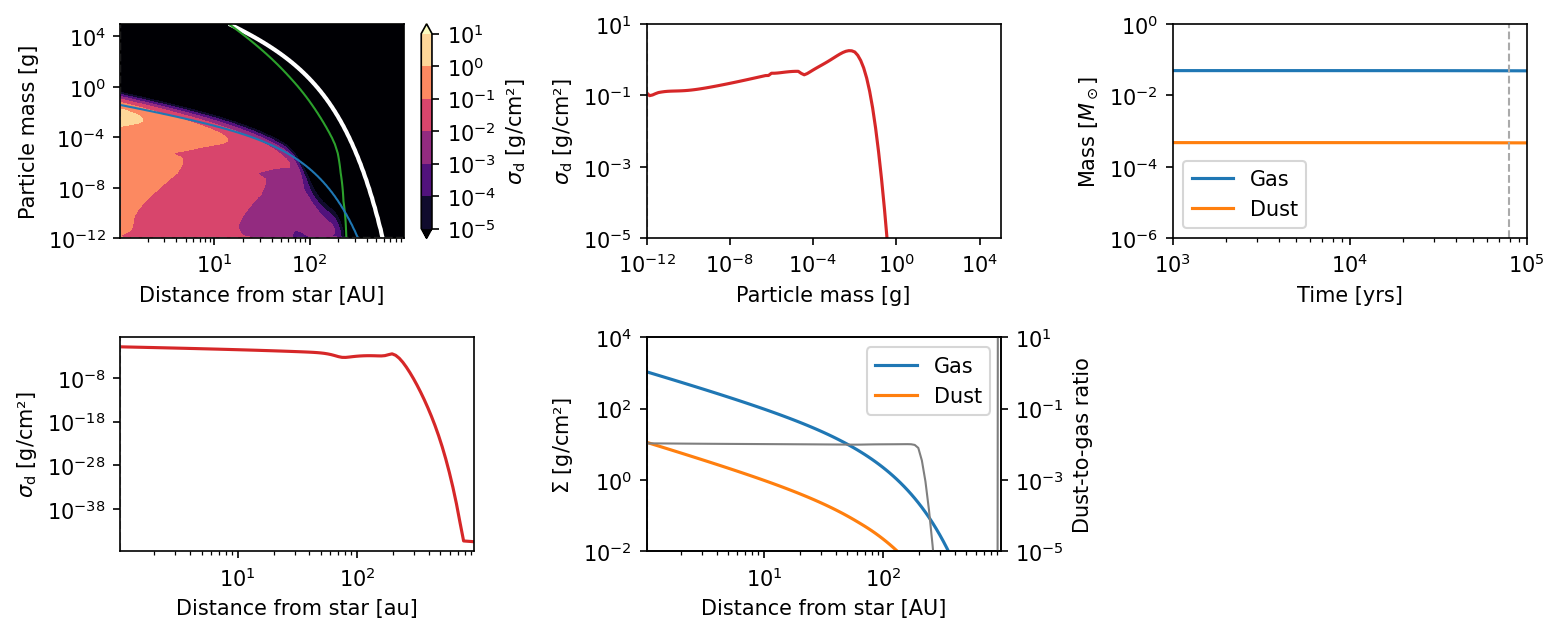

In [13]:
plot.panel("2.2_dustpy_basics", it=20)

DustPy furthermore provides a simple function which is reading in the basic fields, which are needed to create the defaults plots on your own including the growth limits.

In [14]:
from dustpy.utils import read_data

In [15]:
data = read_data("2.2_dustpy_basics")

This functions does not by default return the particles sizes, since the mapping between mass and size is not necessarily constant within the disk due to changes for example in porosity. We have to read this field manually if we want to use it we do this by utilizing the writer.

In [16]:
data.dust.a = sim.writer.read.sequence("dust.a")

Let us assume we want to plot the dust size distribution at a certain time.

In [17]:
from dustpy import constants as c

In [18]:
t0 = 1.e4 * c.year

We need to know which time index is closest to the desired time.

In [19]:
import numpy as np

In [20]:
it = np.abs(data.t-t0).argmin()

Additionally we create some usefull levels of dust surface density for the colormap.

In [21]:
smax = np.ceil(np.log10(data.dust.sigma.max()))
levels = np.arange(smax-6, smax+1)

With this we can create one of the default plots.

In [22]:
import matplotlib.pyplot as plt
plt.rcParams["figure.dpi"] = 150.

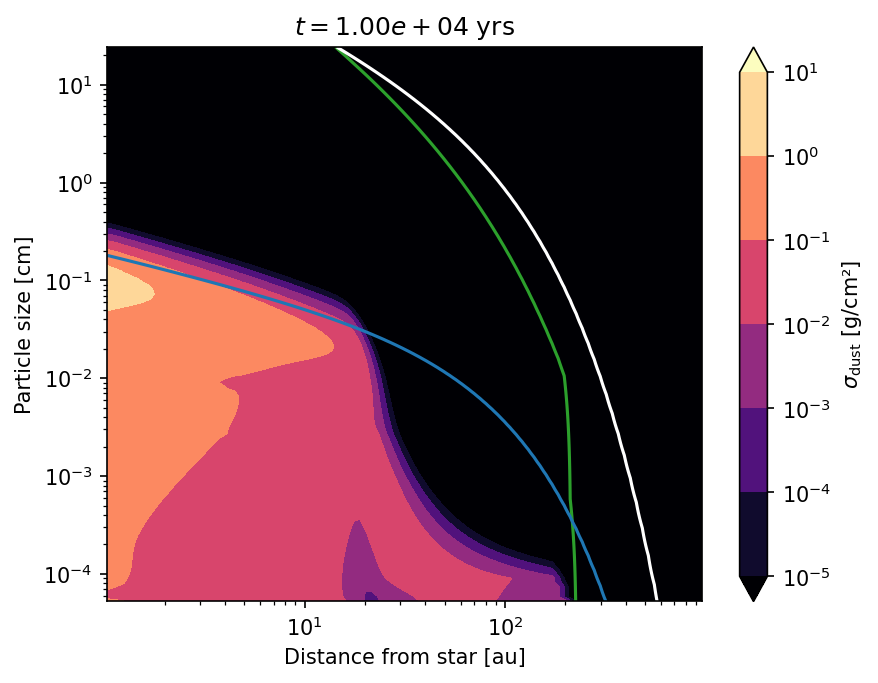

In [23]:
fig, ax = plt.subplots()
plot = ax.contourf(data.grid.r[it, ...]/c.au, data.dust.a[it, 0, :], np.log10(data.dust.sigma[it, ...].T), cmap="magma", levels=levels, extend="both")
ax.contour(data.grid.r[it, ...]/c.au, data.dust.a[it, 0, :], (data.dust.St_limits.drift[..., None]-data.dust.St)[it, ...].T, levels=[0], colors="C2")
ax.contour(data.grid.r[it, ...]/c.au, data.dust.a[it, 0, :], (data.dust.St_limits.frag[..., None]-data.dust.St)[it, ...].T, levels=[0], colors="C0")
ax.contour(data.grid.r[it, ...]/c.au, data.dust.a[it, 0, :], data.dust.St[it, ...].T, levels=[1.], colors="white")
cbar = plt.colorbar(plot)
cbar.set_label(r"$\sigma_\mathrm{dust}$ [g/cm²]")
ticks = cbar.get_ticks()
cbar.set_ticks(ticks)
cbar.set_ticklabels([f"$10^{{{t:.0f}}}$" for t in ticks])
ax.set(
    xscale="log", yscale="log",
    xlabel="Distance from star [au]", ylabel="Particle size [cm]",
    title=f"$t={{{data.t[it]/c.year:.2e}}}$ yrs",
)
fig.set_layout_engine()

## Resuming a simulation

Simulations can be resumed from the dump file which is created by default at every creation of a regular output file.  
Please note that simulations cannot by default be resumed from the *.hdf5 output files, since they do not store information about custom updater to the fields.

You can, however, if you know the customizations manually load data from the output files into a new simulation frame.

Please note furthermore, that dump files are only guaranteed to work if they were created with identical software versions. They are meant for you to resume a (crashed) simulation, but not necessarily to share simulations with colleagues. Be also aware that malware could be injected in dump files. Only load dump files from sources you trust.

In [24]:
from dustpy import readdump

In [25]:
sim_new = readdump("2.2_dustpy_basics/frame.dmp")

In [26]:
print(f"Loaded simulation at t = {sim_new.t/c.year:.2e} yrs.")

Loaded simulation at t = 1.00e+05 yrs.


## Interacting with running simulations

There are complex way to interact with running simulations whose processes you do not have immeadiate access to. Think of a simulation started with a Slurm script. You can still trigger Simframe to write output or dump files from outside without access to the process.

You can furthermore let Slurm send system signals to a running simulation shortly vefore the time limit is reached. Simframe would then write a dump file, stop the simulation, and - if the simulation is not finished - resubmit the Slurm job. Therefore you would need to write a starting script which is distinguishing if the simulation is started freshly or if there is a dump file present from which you can resume the simulation.

For more details, please check the chapter on [Signal Handling](https://simframe.readthedocs.io/en/latest/7_signal_handling.html) in the [Simframe documentation](https://simframe.readthedocs.io/).